In [1]:
try:
    !pip install -q \
    langgraph \
    langchain \
    langchain-community \
    langchain-google-genai \
    langchain-chroma \
    langchain-groq
    print("Packages installed successfully")
except Exception as e:
    print(f"Error installing packages: {e}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.9/554.9 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 71.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170

In [2]:
from google.colab import drive

try:
    drive.mount('/content/drive')
    print("Drive mounted Successfully")
except Exception as e:
    print(f"Drive mount failed: {e}")

Mounted at /content/drive
Drive mounted Successfully


In [3]:
import os
from google.colab import userdata

try:

    os.environ["GOOGLE_API_KEY"] = (
        userdata.get("Gemini_key")
    )

    GROQ_API_KEY = (
        userdata.get("Groq_Key")
    )

    print("API Keys Loaded Successfully")

except Exception as e:

    print(f"API Key Error: {e}")

API Keys Loaded Successfully


In [4]:
try:
    from typing import TypedDict
    from langgraph.graph import (
        StateGraph,
        START,
        END
    )
    from langchain_chroma import Chroma
    from langchain_google_genai import (
        GoogleGenerativeAIEmbeddings
    )
    from groq import Groq

    print("All Imported successfully")

except Exception as e:
    print(f"Import Error: {e}")

All Imported successfully


Connect ChromaDB

In [5]:
try:

    embeddings = (
        GoogleGenerativeAIEmbeddings(
            model="models/gemini-embedding-001"
        )
    )
    db = Chroma(
        collection_name="wiki_rag",
        embedding_function=embeddings,
        persist_directory=
        "/content/drive/MyDrive/RAG_Internship/chroma_db"
    )
    retriever = db.as_retriever(
        search_kwargs={"k": 5}
    )
    print(
        "Documents:",
        db._collection.count()
    )

except Exception as e:
    print(f"ChromaDB Error: {e}")

Documents: 489


In [6]:
try:
    client = Groq(
        api_key=GROQ_API_KEY
    )
    print("Groq initialized Successfully")

except Exception as e:
    print(f"Groq Error: {e}")

Groq initialized Successfully


In [7]:
class GraphState(TypedDict):

    question: str
    docs: list
    context: str
    answer: str
    error: str

Retrieval Node

In [8]:
def retrieve_node(state):
    try:
        question = state["question"]
        docs = retriever.invoke(
            question
        )
        return {
            "docs": docs
        }
    except Exception as e:
        return {
            "error": str(e)
        }

Validation Node

In [9]:
def validate_node(state):

    try:
        docs = state.get(
            "docs",
            []
        )
        if len(docs) == 0:

            return {
                "error":
                "No relevant documents found."
            }
        return {}

    except Exception as e:
        return {
            "error":
            f"Validation Error: {e}"
        }

Generation Node

In [10]:
def generate_node(state):

    try:

        docs = state["docs"]
        question = state["question"]
        context = "\n\n".join(
            [
                doc.page_content
                for doc in docs
            ]
        )

        prompt = f"""
Answer ONLY using the provided context.
If the answer is not available in the context,
respond with:
I could not find that information in the knowledge base.

Context:
{context}

Question:
{question}
"""

        response = (
            client.chat.completions.create(
                model=
                "llama-3.3-70b-versatile",
                messages=[
                    {
                        "role": "user",
                        "content": prompt
                    }
                ]
            )
        )

        answer = (
            response
            .choices[0]
            .message
            .content
        )
        return {
            "context": context,
            "answer": answer
        }

    except Exception as e:
        return {
            "error":
            f"Generation Error: {e}"
        }

Routing Function

In [11]:
def route_after_validation(
    state
):

    if state.get("error"):

        return "error"

    return "generate"

Graph

In [12]:
try:
    builder = StateGraph(
        GraphState
    )
    print("Graph Builder Created")

except Exception as e:
    print(f"Builder Error: {e}")

Graph Builder Created


In [13]:
try:
    builder.add_node(
        "retrieve",
        retrieve_node
    )
    builder.add_node(
        "validate",
        validate_node
    )
    builder.add_node(
        "generate",
        generate_node
    )
    print("Nodes Added Successfully")

except Exception as e:
    print(f"Node Error: {e}")

Nodes Added Successfully


In [14]:
try:

    builder.add_edge(
        START,
        "retrieve"
    )
    builder.add_edge(
        "retrieve",
        "validate"
    )

    print("Edges Added Successfully")

except Exception as e:
    print(f"Edge Error: {e}")

Edges Added Successfully


In [15]:
try:

    builder.add_conditional_edges(
        "validate",
        route_after_validation,
        {
            "generate":
            "generate",

            "error":
            END
        }
    )
    print("Conditional Edge Added")

except Exception as e:
    print(
        f"Conditional Edge Error: {e}"
    )

Conditional Edge Added


In [16]:
try:

    builder.add_edge(
        "generate",
        END
    )
    graph = builder.compile()

    print("Graph Compiled Successfully")

except Exception as e:
    print(f"Compile Error: {e}")

Graph Compiled Successfully


In [18]:
try:
    question = "What is machine learning?"
    result = graph.invoke({"question": question})

    print(f"Question: {question}")
    output = result.get("answer") or result.get("error")
    print(f"\nFinal Output:\n{output}")
except Exception as e:
    print(f"Error processing query: {e}")


Question: What is machine learning?

Final Output:
Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without being explicitly programmed.


In [19]:
try:
    question = "What is AI?"
    result = graph.invoke({"question": question})

    print(f"Question: {question}")
    output = result.get("answer") or result.get("error")
    print(f"\nFinal Output:\n{output}")
except Exception as e:
    print(f" Error processing query: {e}")

Question: What is AI?

Final Output:
Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in engineering, mathematics, and computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.


In [20]:
try:
    question = "Who won FIFA World Cup 2022?"
    result = graph.invoke({"question": question})

    print(f"Question: {question}")
    output = result.get("answer") or result.get("error")
    print(f"\nFinal Output:\n{output}")
except Exception as e:
    print(f" Error processing query: {e}")

Question: Who won FIFA World Cup 2022?

Final Output:
I could not find that information in the knowledge base.


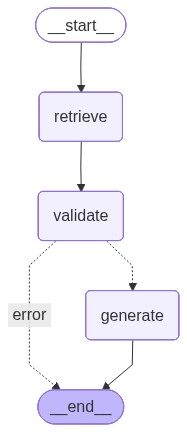

In [ ]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

# Notebook Documentation

## Overview
This notebook implements a RAG pipeline using LangGraph, a framework for building stateful, multi-step LLM applications. It creates a graph-based workflow for retrieval, validation, and generation.

## Dependencies
- langgraph, langchain, langchain-community
- langchain-google-genai, langchain-chroma, langchain-groq

## Core Concepts

### LangGraph
A framework for building stateful, multi-actor LLM applications using graph architecture:
- **Nodes**: Processing steps (retrieve, validate, generate)
- **Edges**: Connections between nodes
- **State**: Shared data passed between nodes
- **Conditional Edges**: Dynamic routing based on state

### StateGraph
Manages workflow state across nodes:
```python
class GraphState(TypedDict):
    question: str    # User query
    docs: list       # Retrieved documents
    context: str     # Combined context
    answer: str      # Generated answer
    error: str       # Error messages
```
## Nodes in This Graph

| Node | Function |
|------|----------|
| **Retrieve Node** | Fetches relevant chunks from ChromaDB |
| **Validate Node** | Checks if documents were retrieved |
| **Generate Node** | Creates answer using Groq Llama 3.3 |

## Conditional Routing

Validates retrieval success before generation:

| Condition | Action |
|-----------|--------|
| If docs found | → proceed to generate |
| If no docs | → end gracefully with error |

## Prerequisite

Must run `Ingestion.ipynb` first to create:
- ChromaDB with 245 chunks from Wikipedia
- Vector embeddings stored in Google Drive

## Configuration

### API Keys Required

| Secret Name | Purpose |
|-------------|---------|
| `Gemini_key` | Generate query embeddings |
| `Groq_Key` | Access Llama 3.3 model |

## Code Structure

| Cell | Function |
|------|----------|
| 1 | Install dependencies |
| 2 | Mount Google Drive |
| 3 | Load API keys (Gemini, Groq) |
| 4 | Import libraries |
| 5 | Connect ChromaDB & create retriever |
| 6 | Initialize Groq client |
| 7 | Define GraphState |
| 8-10 | Define nodes (retrieve, validate, generate) |
| 11 | Define routing function |
| 12-16 | Build and compile graph |
| 17-19 | Execute test queries |